In [ ]:
# pip install sdv

In [ ]:
# pip install torch

In [ ]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import random
import copy
import math
from math import ceil
from sdv.evaluation.single_table import evaluate_quality
from sdmetrics.single_column import BoundaryAdherence
import json


# Data

In [ ]:
url = 'https://github.com/KSTSV/diploma/raw/main/%D0%B8%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D1%8B%D0%B9%20%D0%BC%D0%B0%D1%81%D1%81%D0%B8%D0%B2%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.xlsx'
data = pd.read_excel(url).drop(['ID', 'town'], axis=1)
data = data.replace(99999999, np.nan)

# data = data.dropna()

NameError: name 'np' is not defined

In [ ]:
# data.isna().sum().to_excel("missings_stata.xlsx")

In [ ]:
data.shape

(255, 46)

In [ ]:
# стратегия 4

# fdata = pd.DataFrame()
# for col in data.columns:
#   numerical_distributions = {}
#   sd = data.loc[list(data[col].dropna().index)]

#   metadata = SingleTableMetadata()
#   metadata.detect_from_dataframe(sd)

#   if col not in cat_cols:
#     numerical_distributions[i] = dist_types[np.random.randint(6)]

#   synthesizer = GaussianCopulaSynthesizer(metadata,
#                                           enforce_min_max_values=True,
#                                           numerical_distributions = numerical_distributions)

#   synthesizer.fit(data=sd)
#   fdata[col]  = synthesizer.sample(num_rows=255)[col]



In [ ]:
impmot = ['impmot1', 'impmot2', 'impmot3', 'impmot4', 'impmot5',
       'impmot6', 'impmot7', 'impmot8', 'impmot9']
mot = ['mot1', 'mot2', 'mot3', 'mot4',
       'mot5', 'mot6', 'mot7', 'mot8', 'mot9', 'mot10', 'mot11', 'mot12',
       'mot13', 'mot14']

fctr_succ = ['fctr_succ1', 'fctr_succ2', 'fctr_succ3',
       'fctr_succ4']

In [ ]:
cat_cols = ['gndr', 'marital_stat', 'initiative1_employer',
       'initiative2_persona', 'money_what_employer', 'money_what_persona',
       'money_what_free_other', 'is_spec_crs', 'profwrk']

ord_cols = ['edu', 'change_sal',
       'title_wrk', 'incm']

int_cols = data.drop(cat_cols, axis=1).drop(ord_cols, axis=1).columns

(array([ 4., 15., 18., 28., 14., 33., 27., 34., 16., 12., 16.,  8., 13.,
         2.,  6.,  1.,  3.,  2.,  1.,  1.]),
 array([19.  , 21.55, 24.1 , 26.65, 29.2 , 31.75, 34.3 , 36.85, 39.4 ,
        41.95, 44.5 , 47.05, 49.6 , 52.15, 54.7 , 57.25, 59.8 , 62.35,
        64.9 , 67.45, 70.  ]),
 <BarContainer object of 20 artists>)

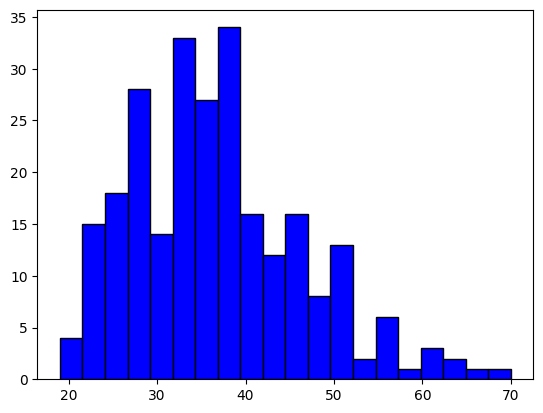

In [ ]:
plt.hist(data['agea'], color = 'blue', edgecolor = 'black',
         bins = int(20))

In [ ]:
dist_types = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma' , 'gaussian_kde']

In [ ]:
mcar = ["marital_stat", "num_crs",
        "mot2", "mot6",  "mot9", "mot10", "mot11", "mot12", "mot13",
        "agewrk", "plcwrk", "sat_wrk",
        "fctr_succ3", "fctr_succ4",
        "impmot1", "impmot4", "impmot5", "impmot8", "agea", "incm", "title_wrk"]

mar = ["mot1", "mot3", "mot4", "mot5", "mot7", "mot8", "mot14",
       "edu", "profwrk", "change_sal", "sal", "fctr_succ1",
       "fctr_succ2", "impmot2", "impmot3", "impmot6", "impmot7", "impmot9"]

In [ ]:
data['incm'].value_counts()

,count
incm,
3.0,171
2.0,40
4.0,24
1.0,9


In [ ]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


for var in data.columns:
  if var not in cat_cols and var not in ord_cols:
    metadata.update_column(column_name=var, sdtype='numerical')
  else:
    metadata.update_column(column_name=var, sdtype='categorical')

  # if var == 'mot13':
  #   dist_types = ['norm', 'truncnorm', 'uniform', 'gamma' , 'gaussian_kde']
  #   numerical_distributions[var] = dist_types[np.random.randint(5)]
  # else:
  #   dist_types = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma' , 'gaussian_kde']
  #   numerical_distributions[var] = dist_types[np.random.randint(6)]

model = GaussianCopulaSynthesizer(
        metadata,
        enforce_min_max_values=True)
        # numerical_distributions = numerical_distributions)

model.fit(data)
# sl_params[var] = [model.get_learned_distributions()[var]]
d = model.sample(num_rows=10000)
d.head()
# synthetic_data_base[var] = d

,gndr,marital_stat,num_crs,initiative1_employer,initiative2_persona,money_what_employer,money_what_persona,money_what_free_other,is_spec_crs,mot1,...,impmot2,impmot3,impmot4,impmot5,impmot6,impmot7,impmot8,impmot9,agea,incm
0,1,1.0,4.0,0,1,0,0,0,2,6.0,...,4.0,6.0,NaN,3.0,NaN,4.0,3.0,5.0,30.0,3.0
1,2,7.0,13.0,0,1,0,0,0,2,7.0,...,6.0,7.0,4.0,1.0,NaN,2.0,7.0,1.0,44.0,3.0
2,2,5.0,4.0,0,1,0,1,1,2,7.0,...,3.0,6.0,4.0,7.0,2.0,2.0,7.0,5.0,28.0,4.0
3,1,7.0,5.0,0,1,1,1,0,1,6.0,...,3.0,2.0,2.0,1.0,7.0,7.0,7.0,4.0,45.0,3.0
4,2,1.0,11.0,0,1,0,1,0,1,7.0,...,5.0,5.0,6.0,7.0,4.0,3.0,7.0,1.0,27.0,1.0


In [ ]:
train_df = d.dropna()
train_df.shape
train_df = train_df.reset_index(drop=True)

train_df.to_excel('train_data.xlsx')

In [ ]:
train_df

,gndr,marital_stat,num_crs,initiative1_employer,initiative2_persona,money_what_employer,money_what_persona,money_what_free_other,is_spec_crs,mot1,...,impmot2,impmot3,impmot4,impmot5,impmot6,impmot7,impmot8,impmot9,agea,incm
0,2,5.0,4.0,0,1,0,1,1,2,7.0,...,3.0,6.0,4.0,7.0,2.0,2.0,7.0,5.0,28.0,4.0
1,1,7.0,4.0,1,1,1,1,0,1,7.0,...,5.0,5.0,3.0,6.0,7.0,6.0,7.0,6.0,49.0,3.0
2,1,7.0,13.0,1,1,1,0,0,2,7.0,...,3.0,5.0,6.0,6.0,7.0,6.0,2.0,2.0,28.0,3.0
3,1,2.0,2.0,0,1,0,0,1,2,7.0,...,7.0,5.0,7.0,7.0,7.0,6.0,7.0,4.0,29.0,3.0
4,1,1.0,6.0,0,1,1,1,1,2,4.0,...,4.0,3.0,5.0,3.0,2.0,2.0,3.0,1.0,30.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,1,7.0,5.0,0,1,1,1,0,1,7.0,...,4.0,5.0,3.0,2.0,2.0,2.0,3.0,1.0,50.0,2.0
974,2,2.0,11.0,0,1,1,0,0,2,7.0,...,2.0,6.0,2.0,5.0,5.0,4.0,5.0,3.0,45.0,3.0
975,1,7.0,2.0,0,1,0,0,1,2,7.0,...,3.0,6.0,4.0,5.0,2.0,1.0,5.0,2.0,27.0,3.0
976,1,7.0,6.0,0,1,0,1,0,2,7.0,...,3.0,6.0,5.0,6.0,5.0,4.0,3.0,1.0,38.0,3.0


# ФУНКЦИИ

### motivation 1

In [ ]:

def mot1 (data, i):
  i=0.0275
  data = copy.deepcopy(data)
  ss = data[data['money_what_employer'] == 1]['mot1']
  ss1 = data[data['money_what_employer'] == 0]['mot1']
  if ceil(255*i) <= len(list(ss.index)):
    r = random.sample(list(ss.index), ceil(255*i))
    ss.loc[r] = np.nan
    data.loc[ss.index, ['mot1']] = ss
  else:
    ss.loc[list(ss.index)] = np.nan
    r1 = ceil(255*i) - len(list(ss.index))
    r2 = random.sample(list(ss1.index), r1)
    ss1.loc[r2] = np.nan
    data.loc[ss1.index, ['mot1']] = ss1
    data.loc[ss.index, ['mot1']] = ss


  return data

# mot1(data, 0.5)

### motivation 3

In [ ]:
# motivation 3
def mot3 (data, i):
  i = 0.0314
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.625 / 0.375) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.625 / 0.375) )
  if (x1 > data[data['plcwrk'] <= 6].shape[0]) or (x2 > data[data['plcwrk'] > 6].shape[0]):
      print(True)
      if data[data['plcwrk'] <= 6].shape[0] > data[data['plcwrk'] > 6].shape[0]:
        x1 = random.choice(range(ceil(255*i - min(data[data['plcwrk'] >6].shape[0], data[data['plcwrk'] <=6].shape[0])+1), ceil(255*i)+1))
      else:
        x1 = random.choice(range(1, min(data[data['plcwrk'] <= 6].shape[0], data[data['plcwrk'] > 6].shape[0])+1))

      x2 = ceil(255*i) - x1

  ss1 = data[data['plcwrk'] <= 6]['mot3']
  r1 = random.sample(list(ss1.index), x1)
  ss1.loc[r1] = np.nan
  data.loc[ss1.index, ['mot3']] = ss1


  ss2 = data[data['plcwrk'] > 6]['mot3']
  r2 = random.sample(list(ss2.index), x2)
  ss2.loc[r2] = np.nan
  data.loc[ss2.index, ['mot3']] = ss2

  return(data)

# mot3(aaa, 0.5)

### motivation 4

In [ ]:
def mot4 (data, i):
  i = 0.0314
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.625 / 0.375) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.625 / 0.375) )
  if (x1 > data[data['plcwrk'] <= 6].shape[0]) or (x2 > data[data['plcwrk'] > 6].shape[0]):
      print(True)
      if data[data['plcwrk'] <= 6].shape[0] > data[data['plcwrk'] > 6].shape[0]:
        x1 = random.choice(range(ceil(255*i - min(data[data['plcwrk'] >6].shape[0], data[data['plcwrk'] <=6].shape[0])+1), ceil(255*i)+1))
      else:
        x1 = random.choice(range(1, min(data[data['plcwrk'] <= 6].shape[0], data[data['plcwrk'] > 6].shape[0])+1))

      x2 = ceil(255*i) - x1

  ss1 = data[data['plcwrk'] <= 6]['mot4']
  r1 = random.sample(list(ss1.index), x1)
  ss1.loc[r1] = np.nan
  data.loc[ss1.index, ['mot4']] = ss1


  ss2 = data[data['plcwrk'] > 6]['mot4']
  r2 = random.sample(list(ss2.index), x2)
  ss2.loc[r2] = np.nan
  data.loc[ss2.index, ['mot4']] = ss2

  return(data)
# mot4(aaa, 0.3)

### motivation 5

In [ ]:
# motivation 5

def mot5 (data, i):
  i = 0.0392
  data = copy.deepcopy(data)
  x2 = ceil(255*i / (1 + 0.6 / 0.4) )
  x1 = ceil(255*i)-ceil(255*i / (1 + 0.6 / 0.4) )
  if (x1 > data[data['is_spec_crs'] == 1].shape[0]) or (x2 > data[data['is_spec_crs'] == 2].shape[0]):
    print(True)
    if data[data['is_spec_crs'] == 1].shape[0] > data[data['is_spec_crs'] == 2].shape[0]:
      x1 = random.choice(range(ceil(255*i - min(data[data['is_spec_crs'] == 1].shape[0], data[data['is_spec_crs'] == 2].shape[0])+1), ceil(255*i)+1))
    else:
      x1 = random.choice(range(1, min(data[data['is_spec_crs'] == 1].shape[0], data[data['is_spec_crs'] == 2].shape[0])+1))
    x2 = ceil(255*i) - x1

  ss3 = data[data['is_spec_crs'] == 1]['mot5']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['mot5']] = ss3

  ss4 = data[data['is_spec_crs'] == 2]['mot5']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['mot5']] = ss4

  return (data)

# mot5(aaa, 0.5)

### motivation 7

In [ ]:
def mot7 (data, i):
  i = 0.0392
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.6 / 0.4) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.6 / 0.4) )

  if (x1 > data[data['impmot2'] <= 3].shape[0]) or (x2 > data[data['impmot2'] > 3].shape[0]):
    print(True)
    # x2 = random.choice(range(1, min(data[data['impmot1'] <= 6].shape[0], data[data['impmot1'] > 6].shape[0])+1))
    # x1 = ceil(255*i) - x2

    if data[data['impmot2'] <= 3].shape[0] > data[data['impmot2'] > 3].shape[0]:
      x1 = random.choice(range(ceil(255*i - min(data[data['impmot2'] <= 3].shape[0], data[data['impmot2'] > 3].shape[0])), ceil(255*i)+1))
    else:
      x1 = random.choice(range(1, min(data[data['impmot2'] <= 3].shape[0], data[data['impmot2'] > 3].shape[0])+1))



  x2 = ceil(255*i) - x1
  # print(x1, x2)

  # print(data[data['impmot1'] <= 6].shape, data[data['impmot1'] > 6].shape)


  ss3 = data[data['impmot2'] <= 3]['mot7']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['mot7']] = ss3

  ss4 = data[data['impmot2'] > 3]['mot7']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['mot7']] = ss4

  return data

In [ ]:
# synthetic_data_base.columns

In [ ]:
# mot7(synthetic_data, 0.1)['mot7'].isna().sum()

### motivation 8

In [ ]:
# motivation 8
def mot8 (data, i):
  i = 0.0471
  data1 = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.58 / 0.42) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.58 / 0.42) )
  # print(x1, x2)

  if (x1 > data1[data1['title_wrk'] <= 2].shape[0]) or (x2 > data1[data1['title_wrk'] > 2].shape[0]):
    print(True)
    x1 = random.choice(range(ceil(255*i - min(data1[data1['title_wrk'] <= 2].shape[0], data1[data1['title_wrk'] > 2].shape[0])), ceil(255*i)+1))
    x2 = ceil(255*i) - x1
    # print(x1, x2)

  # print(data1[data1['title_wrk'] <= 2].shape[0], data1[data1['title_wrk'] > 2].shape[0])

  ss1 = data1[data1['title_wrk'] <= 2]['mot8']
  r1 = random.sample(list(ss1.index), x1)
  ss1.loc[r1] = np.nan
  data1.loc[ss1.index, ['mot8']] = ss1


  ss2 = data1[data1['title_wrk'] > 2]['mot8']
  r2 = random.sample(list(ss2.index), x2)
  ss2.loc[r2] = np.nan
  data1.loc[ss2.index, ['mot8']] = ss2

  return data1


# mot8(synthetic_data, 0.5)

### motivation 14

In [ ]:
# motivation 14
def mot14 (data, i):
  i = 0.051
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.58 / 0.42) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.58 / 0.42) )

  if (x1 > data[data['mot2'] <= 5].shape[0]) or (x2 > data[data['mot2'] > 5].shape[0]):
      print(True)
      if data[data['mot2'] <= 5].shape[0] > data[data['mot2'] > 5].shape[0]:
        x1 = random.choice(range(ceil(255*i - min(data[data['mot2'] <= 5].shape[0], data[data['mot2'] > 5].shape[0])), ceil(255*i)+1))
      else:
        x1 = random.choice(range(1, min(data[data['mot2'] <= 5].shape[0], data[data['mot2'] > 5].shape[0])+1))

      x2 = ceil(255*i) - x1
      # print(x1, x2)
  # print(data[data['mot2'] <= 5].shape[0], data[data['mot2'] > 5].shape[0])


  ss1 = data[data['mot2'] <= 5]['mot14']
  r1 = random.sample(list(ss1.index), x1)
  ss1.loc[r1] = np.nan
  data.loc[ss1.index, ['mot14']] = ss1


  ss2 = data[data['mot2'] > 5]['mot14']
  r2 = random.sample(list(ss2.index), x2)
  ss2.loc[r2] = np.nan
  data.loc[ss2.index, ['mot14']] = ss2

  return data

# mot14(s, 0.5)

### edu

In [ ]:
# edu
def edu (data, i):
  i = 0.018
  data = copy.deepcopy(data)
  ss = data[data['incm'] <= 2]['edu']
  ss1 = data[data['incm'] > 2]['edu']
  if ceil(255*i) <= len(list(ss.index)):
    r = random.sample(list(ss.index), ceil(255*i))
    ss.loc[r] = np.nan
    data.loc[ss.index, ['edu']] = ss
  else:
    ss.loc[list(ss.index)] = np.nan
    r1 = ceil(255*i) - len(list(ss.index))

    r2 = random.sample(list(ss1.index), r1)
    ss1.loc[r2] = np.nan

    r3 = random.sample(list(ss.index), ceil(255*i) - r1)
    ss.loc[r3] = np.nan

    data.loc[ss1.index, ['edu']] = ss1
    data.loc[ss.index, ['edu']] = ss



  return data

# edu(aaa, 0.5)

### profwrk

In [ ]:
# profwrk
def profwrk  (data, i):
  i = 0.0902
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.91 / 0.09) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.91 / 0.09) )

  if (x1 > data[data['is_spec_crs'] == 1].shape[0]) or (x2 > data[data['is_spec_crs'] == 2].shape[0]):
    print(True)
    x1 = random.choice(range(ceil(255*i - min(data[data['is_spec_crs'] == 1].shape[0], data[data['is_spec_crs'] == 2].shape[0])), ceil(255*i)+1))
    x2 = ceil(255*i) - x1


  ss3 = data[data['is_spec_crs'] == 1]['profwrk']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['profwrk']] = ss3

  ss4 = data[data['is_spec_crs'] == 2]['profwrk']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['profwrk']] = ss4

  return data
# profwrk(aaa, 0.5)

### change_sal

In [ ]:
# change_sal
def change_sal  (data, i):
  i = 0.149
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.66 / 0.34) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.66 / 0.34) )
  # print(x1, x2)

  if (x1 > data[data['sal'] <= 300000].shape[0]) or (x2 > data[data['sal'] > 300000].shape[0]):
    print(True)
    x1 = random.choice(range(ceil(255*i - min(data[data['sal'] <= 300000].shape[0], data[data['sal'] > 300000].shape[0])), ceil(255*i)+1))
    x2 = ceil(255*i) - x1
    # print(x1, x2)

  # print(data[data['sal'] <= 300000].shape[0], data[data['sal'] > 300000].shape[0])



  ss3 = data[data['sal'] <= 300000]['change_sal']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['change_sal']] = ss3

  ss4 = data[data['sal'] > 300000]['change_sal']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['change_sal']] = ss4

  return data


# change_sal(s, 0.1)


###

In [ ]:
# 255*0.1 - min(s[s['sal'] <= 300000].shape[0], s[s['sal'] > 300000].shape[0])

In [ ]:
random.choice(range(25, 27))

26

### title_wrk

In [ ]:
# # title_wrk
# def title_wrk  (data, i):
#   data = copy.deepcopy(data)
#   x1 = ceil(255*i / (1 + 0.53 / 0.47) )
#   x2 = ceil(255*i)-ceil(255*i / (1 + 0.53 / 0.47) )

#   if (x1 > data[data['mot14'] <= 2].shape[0]) or (x2 > data[data['mot14'] > 2].shape[0]):
#     print(True)
#     if data[data['mot14'] <= 2].shape[0] > data[data['mot14'] > 2].shape[0]:
#       x1 = random.choice(range(ceil(255*i - min(data[data['mot14'] <= 2].shape[0], data[data['mot14'] > 2].shape[0])), ceil(255*i)+1))
#     else:
#       x1 = random.choice( range(1, min(data[data['mot14'] <= 2].shape[0], data[data['mot14'] > 2].shape[0])+1))

#     x2 = ceil(255*i) - x1
#     print(x1, x2)

#   print(data[data['mot14'] <= 2].shape[0], data[data['mot14'] > 2].shape[0])


#   ss3 = data[data['mot14'] <= 2]['title_wrk']
#   r3 = random.sample(list(ss3.index), x1)
#   ss3.loc[r3] = np.nan
#   data.loc[ss3.index, ['title_wrk']] = ss3

#   ss4 = data[data['mot14'] > 2]['title_wrk']
#   r4 = random.sample(list(ss4.index), x2)
#   ss4.loc[r4] = np.nan
#   data.loc[ss4.index, ['title_wrk']] = ss4

#   return data


# # title_wrk(s, 0.5)

In [ ]:
data[data['mot14'] <= 2].shape[0]

199

### sal

In [ ]:
# sal
def sal (data, i):
  i = 0,3686
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.67 / 0.33) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.67 / 0.33) )

  if (x1 > data[data['mot13'] <= 1].shape[0]) or (x2 > data[data['mot13'] > 1].shape[0]):
      print(True)
      if data[data['mot13'] <= 1].shape[0] > data[data['mot13'] > 1].shape[0]:
        x1 = random.choice(range(ceil(255*i - min(data[data['mot13'] <= 1].shape[0], data[data['mot13'] > 1].shape[0])), ceil(255*i)+1))
      else:
        x1 = random.choice(range(1, min(data[data['mot13'] <= 1].shape[0], data[data['mot13'] > 1].shape[0])+1))

      x2 = ceil(255*i) - x1
      # print(x1, x2)
  # print(data[data['mot13'] <= 1].shape[0], data[data['mot13'] > 1].shape[0])


  ss3 = data[data['mot13'] <= 1]['sal']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['sal']] = ss3

  ss4 = data[data['mot13'] > 1]['sal']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['sal']] = ss4

  return data

# sal(s, 0.3)

### fctr_succ1

In [ ]:
# fctr_succ1
def fctr_succ1  (data, i):
  i = 0.0549
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.79 / 0.21) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.79 / 0.21) )

  if (x1 > data[data['money_what_employer'] == 1].shape[0]) or (x2 > data[data['money_what_employer'] == 0].shape[0]):
    print(True)
    x1 = random.choice(range(ceil(255*i - min(data[data['money_what_employer'] == 1].shape[0], data[data['money_what_employer'] == 0].shape[0])), ceil(255*i)+1))
    x2 = ceil(255*i) - x1


  ss3 = data[data['money_what_employer'] == 1]['fctr_succ1']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['fctr_succ1']] = ss3

  ss4 = data[data['money_what_employer'] == 0]['fctr_succ1']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['fctr_succ1']] = ss4

  return data

# fctr_succ1(aaa, 0.5)

### fctr_succ2

In [ ]:
# fctr_succ2
def fctr_succ2  (data, i):
  i = 0.0588
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.67 / 0.33) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.67 / 0.33) )

  if (x1 > data[data['money_what_persona'] == 1].shape[0]) or (x2 > data[data['money_what_persona'] == 0].shape[0]):
      print(True)
      x1 = random.choice(range(1, min(data[data['money_what_persona'] == 1].shape[0], data[data['money_what_persona'] == 0].shape[0])+1))
      x2 = ceil(255*i) - x1


  ss3 = data[data['money_what_persona'] == 1]['fctr_succ2']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['fctr_succ2']] = ss3

  ss4 = data[data['money_what_persona'] == 0]['fctr_succ2']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['fctr_succ2']] = ss4

  return data

# fctr_succ2(aaa, 0.5)

### impmot2

In [ ]:
# impmot2

def impmot2  (data, i):
  i = 0.0549
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.79 / 0.21) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.79 / 0.21) )

  if (x1 > data[data['money_what_employer'] == 1].shape[0]) or (x2 > data[data['money_what_employer'] == 0].shape[0]):
    print(True)
    x1 = random.choice(range(ceil(255*i - min(data[data['money_what_employer'] == 1].shape[0], data[data['money_what_employer'] == 0].shape[0])), ceil(255*i)+1))
    x2 = ceil(255*i) - x1

  ss3 = data[data['money_what_employer'] == 1]['impmot2']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['impmot2']] = ss3

  ss4 = data[data['money_what_employer'] == 0]['impmot2']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['impmot2']] = ss4
  return data

# impmot2(aaa, 0.4)

### impmot3

In [ ]:
# impmot3

def impmot3  (data, i):
  i = 0.0588
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.67 / 0.33) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.67 / 0.33) )

  if (x1 > data[data['money_what_persona'] == 1].shape[0]) or (x2 > data[data['money_what_persona'] == 0].shape[0]):
      print(True)
      x1 = random.choice(range(1, min(data[data['money_what_persona'] == 1].shape[0], data[data['money_what_persona'] == 0].shape[0])+1))
      x2 = ceil(255*i) - x1

  ss3 = data[data['money_what_persona'] == 1]['impmot3']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['impmot3']] = ss3

  ss4 = data[data['money_what_persona'] == 0]['impmot3']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['impmot3']] = ss4
  return data

# impmot3(aaa, 0.5)

### impmot6

In [ ]:
# impmot6

def impmot6  (data, i):
  i = 0.0627
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.75 / 0.25) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.75 / 0.25) )

  if (x1 > data[data['money_what_persona'] == 1].shape[0]) or (x2 > data[data['money_what_persona'] == 0].shape[0]):
    print(True)
    x1 = random.choice(range(ceil(255*i - min(data[data['money_what_persona'] == 1].shape[0], data[data['money_what_persona'] == 0].shape[0])), ceil(255*i)+1))
    x2 = ceil(255*i) - x1



  ss3 = data[data['money_what_persona'] == 1]['impmot6']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['impmot6']] = ss3

  ss4 = data[data['money_what_persona'] == 0]['impmot6']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['impmot6']] = ss4
  return data

# impmot6(aaa, 0.5)

### impmot7

In [ ]:
# impmot7

def impmot7  (data, i):
  i = 0.0510
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.54 / 0.46) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.54 / 0.46) )

  if (x1 > data[data['is_spec_crs'] == 1].shape[0]) or (x2 > data[data['is_spec_crs'] == 2].shape[0]):
      print(True)
      x1 = random.choice(range(1, min(data[data['is_spec_crs'] == 1].shape[0], data[data['is_spec_crs'] == 2].shape[0])+1))
      x2 = ceil(255*i) - x1

  ss3 = data[data['is_spec_crs'] == 1]['impmot7']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['impmot7']] = ss3

  ss4 = data[data['is_spec_crs'] == 2]['impmot7']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['impmot7']] = ss4

  return data

# impmot7(aaa, 0.5)

### impmot9

In [ ]:
# impmot9
def impmot9  (data, i):
  i = 0.0941
  data = copy.deepcopy(data)
  x1 = ceil(255*i / (1 + 0.58 / 0.42) )
  x2 = ceil(255*i)-ceil(255*i / (1 + 0.58 / 0.42) )

  if (x1 > data[data['impmot1'] <= 6].shape[0]) or (x2 > data[data['impmot1'] > 6].shape[0]):
    print(True)
    # x2 = random.choice(range(1, min(data[data['impmot1'] <= 6].shape[0], data[data['impmot1'] > 6].shape[0])+1))
    # x1 = ceil(255*i) - x2

    if data[data['impmot1'] <= 6].shape[0] > data[data['impmot1'] > 6].shape[0]:
      x1 = random.choice(range(ceil(255*i - min(data[data['impmot1'] <= 6].shape[0], data[data['impmot1'] > 6].shape[0])), ceil(255*i)+1))
    else:
      x1 = random.choice(range(1, min(data[data['impmot1'] <= 6].shape[0], data[data['impmot1'] > 6].shape[0])+1))



  x2 = ceil(255*i) - x1
  # print(x1, x2)

  # print(data[data['impmot1'] <= 6].shape, data[data['impmot1'] > 6].shape)


  ss3 = data[data['impmot1'] <= 6]['impmot9']
  r3 = random.sample(list(ss3.index), x1)
  ss3.loc[r3] = np.nan
  data.loc[ss3.index, ['impmot9']] = ss3

  ss4 = data[data['impmot1'] > 6]['impmot9']
  r4 = random.sample(list(ss4.index), x2)
  ss4.loc[r4] = np.nan
  data.loc[ss4.index, ['impmot9']] = ss4

  return data

# impmot9(aaa, 0.4)

# Генерация синтетичсеких данных

In [ ]:
synthetic_data = pd.DataFrame(np.array(train_df), columns = train_df.columns)
synthetic_data_final = pd.DataFrame(np.array(train_df), columns = train_df.columns)

In [ ]:


for var in mar:
    if var in mar:

      if var == 'mot1': synthetic_data_final[var] = mot1(synthetic_data, k)[var] # работает, но слишком много пропусков
      elif var == 'mot3': synthetic_data_final[var] =mot3(synthetic_data, k)[var]
      elif var == 'mot4': synthetic_data_final[var] =mot4(synthetic_data, k)[var]
      elif var == 'mot5': synthetic_data_final[var] = mot5(synthetic_data, k)[var]
      elif var == 'mot7': synthetic_data_final[var] = mot7(synthetic_data, k)[var]
      elif var == 'mot8': synthetic_data_final[var] =mot8(synthetic_data, k)[var]
      # elif var == 'title_wrk': synthetic_data_final[var] =title_wrk(synthetic_data, k)[var] # проблема
      elif var == 'mot14': synthetic_data_final[var] =mot14(synthetic_data, k)[var]  # проблема
      elif var == 'edu': synthetic_data_final[var] =edu(synthetic_data, k)[var]
      elif var == 'profwrk': synthetic_data_final[var] =profwrk(synthetic_data, k)[var]
      elif var == 'change_sal': synthetic_data_final[var] =change_sal(synthetic_data, k)[var] # проблема
      elif var == 'fctr_succ1': synthetic_data_final[var] =fctr_succ1(synthetic_data, k)[var]
      elif var == 'fctr_succ2': synthetic_data_final[var] =fctr_succ2(synthetic_data, k)[var]
      elif var == 'impmot2': synthetic_data_final[var] =impmot2(synthetic_data, k)[var]
      elif var == 'impmot3': synthetic_data_final[var] =impmot3(synthetic_data, k)[var]
      elif var == 'impmot6': synthetic_data_final[var] =impmot6(synthetic_data, k)[var]
      elif var == 'impmot7': synthetic_data_final[var] =impmot7(synthetic_data, k)[var]
      elif var == 'impmot9': synthetic_data_final[var] =impmot9(synthetic_data, k)[var] # проблема

for var in mcar:
  if var == 'marital_stat':
    k = 0.0275
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan

  if var == 'num_crs':
    k = 0.431
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan

  if var == 'mot2':
    k = 0.0549
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'mot6':
    k = 0.0353
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'mot9':
    k = 0.0510
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'mot10':
    k = 0.0353
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'mot11':
    k = 0.0275
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'mot12':
    k = 0.0275
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'mot13':
    k = 0.051
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'agewrk':
    k = 0.0039
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'plcwrk':
    k = 0.0039
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'sat_wrk':
    k = 0.1020
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'fctr_succ3':
    k = 0.0275
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'fctr_succ4':
    k = 0.0549
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'impmot1':
    k = 0.0588
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'impmot4':
    k = 0.0275
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'impmot5':
    k = 0.0549
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'impmot8':
    k = 0.0392
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'agea':
    k = 0.0039
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan
  if var == 'incm':
    k = 0.0431
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan

  if var == 'title_wrk':
    k = 0.0667
    r = random.sample(n, ceil(255*k))
    synthetic_data_final.loc[r, [var]] = np.nan


In [ ]:
synthetic_data_final.to_excel('train_mis_data.xlsx')


# Характеристики обущающего датасета

In [ ]:
import pandas as pd

In [ ]:
dfm1 = pd.read_excel('https://github.com/KSTSV/diploma/raw/main/train_mis_data.xlsx')
dft1 = pd.read_excel('https://github.com/KSTSV/diploma/raw/main/train_data.xlsx')

dfm1 = dfm1[sorted(dfm1.columns)].reset_index(drop = True)
dft1 = dft1[sorted(dfm1.columns)].reset_index(drop = True)

dfm1 = dfm1.drop('Unnamed: 0', axis=1)
dft1 = dft1.drop('Unnamed: 0', axis=1)


dft1 = dft1.astype(float)

dfm1 = dfm1.astype(float)

In [ ]:
dft1[ord_cols].describe().T.to_excel('train_stata_ord.xlsx')

In [ ]:
dft1[cat_cols].mode()

,gndr,marital_stat,initiative1_employer,initiative2_persona,money_what_employer,money_what_persona,money_what_free_other,is_spec_crs,profwrk
0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0
1,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
